# Lecture 16: Eigenvalues, Eigenvectors, and the SVD

### The missing hinge between the quantum and AI halves of this course

Lectures 1–10 built up vectors, inner products, matrices, and tensor products.
But one tool was never introduced — and it is arguably *the* central tool of
applied linear algebra, sitting underneath both halves of this course:

- **Quantum:** a measurement's possible outcomes are the **eigenvalues** of an
  observable, and the states it collapses to are the **eigenvectors**. The
  Pauli-Z measurement from Lecture 10 is an eigenvalue problem.
- **AI:** **PCA** — used in Lectures 13 and 15 to compress embeddings — *is* an
  eigenvalue / **SVD** problem. We used it; here we finally derive it.

One idea, both halves. Let's make it concrete.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

## 1. Eigenvectors: directions a matrix only stretches

For a square matrix $A$, an **eigenvector** $v$ is a direction that $A$ does not
rotate — it only scales it by a number, the **eigenvalue** $\lambda$:

$$A v = \lambda v$$

Most vectors get rotated when you apply $A$; eigenvectors are the special few
that keep their direction.

In [2]:
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
vals, vecs = np.linalg.eig(A)
print('eigenvalues:', vals)
for i in range(2):
    v = vecs[:, i]
    print(f'  A @ v{i} = {A @ v}   vs   lambda*v = {vals[i] * v}   (equal -> eigenvector)')

eigenvalues: [3. 1.]
  A @ v0 = [2.121 2.121]   vs   lambda*v = [2.121 2.121]   (equal -> eigenvector)
  A @ v1 = [-0.707  0.707]   vs   lambda*v = [-0.707  0.707]   (equal -> eigenvector)


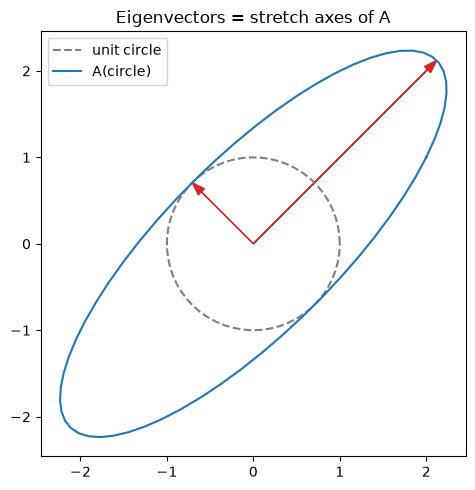

In [3]:
# Visualize: A stretches the plane along its eigenvectors
theta = np.linspace(0, 2*np.pi, 60)
circle = np.stack([np.cos(theta), np.sin(theta)])
ellipse = A @ circle
plt.figure(figsize=(5, 5))
plt.plot(circle[0], circle[1], '--', color='gray', label='unit circle')
plt.plot(ellipse[0], ellipse[1], color='tab:blue', label='A(circle)')
for i in range(2):
    v = vecs[:, i]
    plt.arrow(0, 0, vals[i]*v[0], vals[i]*v[1], head_width=0.1, color='tab:red',
              length_includes_head=True)
plt.gca().set_aspect('equal'); plt.legend(); plt.title('Eigenvectors = stretch axes of A')
plt.tight_layout(); plt.show()

## 2. Symmetric/Hermitian matrices and the quantum connection

A **Hermitian** matrix ($A = A^\dagger$, its conjugate transpose) has two
special properties (the **spectral theorem**): its eigenvalues are **real**, and
its eigenvectors are **orthogonal**. This is exactly why quantum mechanics uses
Hermitian matrices for observables — measurement outcomes are real numbers.

The **Pauli-Z** operator from Lecture 10 is the simplest example. Its
eigenvalues are $+1$ and $-1$ — the two possible measurement outcomes — and its
eigenvectors are $|0\rangle$ and $|1\rangle$, the states you collapse to.

In [4]:
Z = np.array([[1, 0],
              [0, -1]], dtype=complex)
vals, vecs = np.linalg.eigh(Z)   # eigh: for Hermitian matrices (real eigenvalues)
print('Pauli-Z eigenvalues (measurement outcomes):', vals.real)
print('eigenvectors (basis states |0>, |1>):')
print(vecs.real)

X = np.array([[0, 1], [1, 0]], dtype=complex)   # Pauli-X
valsX, vecsX = np.linalg.eigh(X)
print('\nPauli-X eigenvalues:', valsX.real, ' -> eigenvectors are |+>, |-> (superpositions)')
print(vecsX.real)

Pauli-Z eigenvalues (measurement outcomes): [-1.  1.]
eigenvectors (basis states |0>, |1>):
[[0. 1.]
 [1. 0.]]

Pauli-X eigenvalues: [-1.  1.]  -> eigenvectors are |+>, |-> (superpositions)
[[-0.707  0.707]
 [ 0.707  0.707]]


So 'measuring in the Z basis' vs 'the X basis' (Lecture 10's adaptive
measurement) is literally a choice of *which matrix's eigenvectors* you project
onto. Eigen-decomposition is the language of quantum measurement.

## 3. The SVD: every matrix is rotate – stretch – rotate

Not every matrix is square or symmetric. The **Singular Value Decomposition**
works for *any* matrix $M$:

$$M = U \, \Sigma \, V^\top$$

$U$ and $V$ are rotations (orthogonal), and $\Sigma$ is a diagonal stretch by
the **singular values**. Geometrically: every linear map is a rotation, then an
axis-aligned stretch, then another rotation. The singular values tell you how
much 'energy' lies along each direction — the key to compression.

In [5]:
M = np.array([[3.0, 1.0, 1.0],
              [1.0, 3.0, 1.0]])
U, S, Vt = np.linalg.svd(M, full_matrices=False)
print('singular values:', S)
reconstructed = U @ np.diag(S) @ Vt
print('U @ S @ Vt reproduces M?', np.allclose(reconstructed, M))

singular values: [4.243 2.   ]
U @ S @ Vt reproduces M? True


## 4. Low-rank approximation: keep the biggest singular values

Because the largest singular values carry the most 'energy', keeping only the
top few gives the **best low-rank approximation** of a matrix. This is exactly
how PCA compresses data and how images/embeddings are compressed. We'll show it
on a simple image (a smooth gradient + structure).

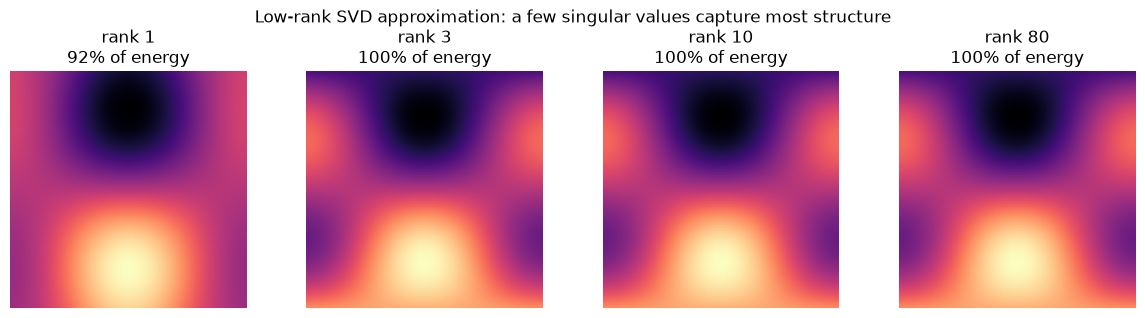

In [6]:
# Build a small structured 'image'
x = np.linspace(-3, 3, 80)
img = np.outer(np.sin(x), np.cos(x)) + 0.3 * np.outer(x, np.ones_like(x))
U, S, Vt = np.linalg.svd(img)

def rank_k(k):
    return (U[:, :k] * S[:k]) @ Vt[:k]

fig, ax = plt.subplots(1, 4, figsize=(12, 3.2))
for a, k in zip(ax, [1, 3, 10, len(S)]):
    a.imshow(rank_k(k), cmap='magma'); a.axis('off')
    energy = (S[:k]**2).sum() / (S**2).sum()
    a.set_title(f'rank {k}\n{energy:.0%} of energy')
plt.suptitle('Low-rank SVD approximation: a few singular values capture most structure')
plt.tight_layout(); plt.show()

## 5. PCA is an SVD — closing the loop with Lectures 13 & 15

In Lectures 13 and 15 we called `PCA(...)` to compress 384-dimensional
embeddings. PCA is just: **center the data, then take the SVD** — the principal
components are the right-singular vectors, and the variance explained by each is
its singular value squared. Let's verify that `sklearn`'s PCA and a hand-rolled
SVD give the same thing.

In [7]:
from sklearn.decomposition import PCA
rng = np.random.default_rng(0)
data = rng.normal(size=(200, 5)) @ rng.normal(size=(5, 5))   # correlated 5-D data

# Hand-rolled PCA via SVD
centered = data - data.mean(axis=0)
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
var_svd = (S**2) / (len(data) - 1)

pca = PCA().fit(data)
print('variance per component (SVD)    :', var_svd[:5])
print('variance per component (sklearn):', pca.explained_variance_[:5])
print('\nmatch?', np.allclose(var_svd, pca.explained_variance_))

variance per component (SVD)    : [9.003 3.493 1.39  0.389 0.004]
variance per component (sklearn): [9.003 3.493 1.39  0.389 0.004]

match? True


## Recap — the tool that runs under everything

| Concept | Quantum half | AI half |
|---------|--------------|---------|
| Eigenvalues | Measurement outcomes (Pauli-Z: $\pm1$) | Variance along a principal direction |
| Eigenvectors | Basis states you collapse to ($\lvert0\rangle,\lvert1\rangle$) | Principal components |
| Hermitian/spectral theorem | Why observables have real outcomes | Symmetric covariance ⇒ real PCA axes |
| SVD | — | Compresses embeddings/images; PCA itself |

Eigen-decomposition and the SVD are where this course's two threads turn out to
be the **same mathematics**: finding the special directions of a linear map.
That is the deepest version of the methodology's claim that *meaning — and
measurement — is geometry*.

## Exercises

1. Confirm the spectral theorem numerically: build a random symmetric matrix
   `A = B + B.T` and check its eigenvectors are orthogonal (`Q.T @ Q ≈ I`).
2. Take the embeddings from Lecture 12, run the SVD, and plot the singular-value
   spectrum. How many components capture 90% of the variance?
3. Show that the Hadamard gate's eigenvectors are the states it leaves unchanged
   (up to sign). What are its eigenvalues?
4. Compress a grayscale photo with rank-$k$ SVD and plot reconstruction error vs
   $k$. Where is the 'elbow'?
5. Relate this back to Lecture 15: if you keep only the top-2 PCA components for
   the quantum classifier, what fraction of the embedding variance reaches the
   circuit?